In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/diabetic_data.csv")

In [3]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
print("Shape:", df.shape)



Shape: (101766, 50)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [6]:
print("Rows, Columns:", df.shape)

Rows, Columns: (101766, 50)


In [7]:
df.columns.tolist()

['encounter_id',
 'patient_nbr',
 'race',
 'gender',
 'age',
 'weight',
 'admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'payer_code',
 'medical_specialty',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'diag_1',
 'diag_2',
 'diag_3',
 'number_diagnoses',
 'max_glu_serum',
 'A1Cresult',
 'metformin',
 'repaglinide',
 'nateglinide',
 'chlorpropamide',
 'glimepiride',
 'acetohexamide',
 'glipizide',
 'glyburide',
 'tolbutamide',
 'pioglitazone',
 'rosiglitazone',
 'acarbose',
 'miglitol',
 'troglitazone',
 'tolazamide',
 'examide',
 'citoglipton',
 'insulin',
 'glyburide-metformin',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed',
 'readmitted']

In [8]:
df['readmitted'].value_counts()

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

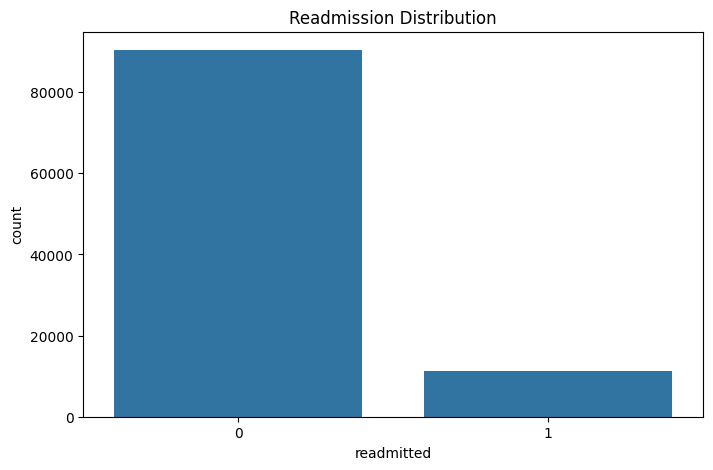

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(x='readmitted', data=df)
plt.title('Readmission Distribution')
plt.savefig('../reports/readmission_distribution.png')
plt.show()



In [10]:
df['readmitted'].unique()

<ArrowStringArray>
['NO', '>30', '<30']
Length: 3, dtype: str

In [11]:
(df == '?').sum().sort_values(ascending=False)

weight                      98569
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
admission_type_id               0
patient_nbr                     0
encounter_id                    0
time_in_hospital                0
admission_source_id             0
num_lab_procedures              0
num_procedures                  0
num_medications                 0
discharge_disposition_id        0
gender                          0
age                             0
number_inpatient                0
number_emergency                0
number_outpatient               0
number_diagnoses                0
max_glu_serum                   0
A1Cresult                       0
metformin                       0
repaglinide                     0
nateglinide                     0
chlorpropamide                  0
glimepiride                     0
acetohexamide 

In [12]:
df.replace('?', np.nan, inplace=True)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),NaN,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),NaN,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),NaN,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),NaN,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


# Missing Value Analysis

Objective:
Identify columns with significant missing values and determine whether they should be removed or imputed.

Reason:
Features with excessive missing values may reduce model quality and require special handling.

In [13]:
# Calculate missing value count and percentage

missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

# Display columns having missing values

missing_df[missing_df['Missing Count'] > 0].sort_values(
    by='Missing Percentage',
    ascending=False
)

,Missing Count,Missing Percentage
weight,98569,96.858479
max_glu_serum,96420,94.746772
A1Cresult,84748,83.277322
medical_specialty,49949,49.082208
payer_code,40256,39.557416
race,2273,2.233555
diag_3,1423,1.398306
diag_2,358,0.351787
diag_1,21,0.020636


## Column Removal Analysis

Objective:
Remove identifier columns and features with extremely poor data quality.

Reason:

1. encounter_id and patient_nbr are identifiers and contain no predictive information.
2. weight contains approximately 97% missing values.
3. payer_code contains approximately 40% missing values and has limited clinical relevance.

In [14]:
# Remove identifier columns and highly incomplete columns

df.drop(
    [
        'encounter_id',   # Unique encounter identifier
        'patient_nbr',    # Unique patient identifier
        'weight',         # 96.85% missing values
        'payer_code'      # 39.55% missing values
    ],
    axis=1,
    inplace=True
)

# Display new dataset shape

print("Dataset Shape:", df.shape)

Dataset Shape: (101766, 46)


I intentionally don't want to drop max_glu_serum and A1Cresult yet.

Why?

Because these are clinically important diabetes-related features and may carry predictive power even though they have many missing values.

# Target Variable Analysis

Objective:
Understand the distribution of the target variable (readmitted).

Reason:
Before converting the problem into binary classification, we need to inspect the classes and check for class imbalance.

Expected Classes:
- NO
- less than 30
- greater than 30

Business Goal:
Predict whether a patient will be readmitted within 30 days after discharge.

In [15]:
# Display the frequency of each readmission category

print("Readmission Distribution:\n")

print(df['readmitted'].value_counts())

# Display unique values present in the target column

print("\nUnique Values:")

print(df['readmitted'].unique())

Readmission Distribution:

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Unique Values:
<ArrowStringArray>
['NO', '>30', '<30']
Length: 3, dtype: str


Observation:

The target variable contains three classes:
- NO
- less than 30
- greater than 30

Since the objective of the project is to identify patients who are readmitted within 30 days, the problem is converted into binary classification.

Decision:
- greater than (>)30 is mapped to 1 (Early Readmission)
- less than (<)30 and NO are mapped to 0 (No Early Readmission)

## Class Imbalance Analysis

Objective:
Determine whether the target classes are balanced.

Reason:
Machine learning models may become biased toward the majority class if the dataset is highly imbalanced.

This analysis will help us decide whether techniques such as class weighting or resampling are needed.

In [16]:
# Calculate percentage distribution of target classes

target_distribution = (
    df['readmitted']
    .value_counts(normalize=True) * 100
)

print("Class Distribution (%):\n")

print(target_distribution)

Class Distribution (%):

readmitted
NO     53.911916
>30    34.928169
<30    11.159916
Name: proportion, dtype: float64


This means:

Only 11.16% of patients were readmitted within 30 days.

So after conversion:

1 (<30)  = 11.16%
0 (NO + >30) = 88.84%

The dataset will become imbalanced

In [17]:
# Count patients that will become class 0

print("Class 0 Count:")

print(
    len(df[df['readmitted'] == 'NO']) +
    len(df[df['readmitted'] == '>30'])
)

print("\nClass 1 Count:")

print(
    len(df[df['readmitted'] == '<30'])
)

Class 0 Count:
90409

Class 1 Count:
11357


# Class Imbalance Analysis

## Observation

After analyzing the target variable, the class distribution was found to be:

- Class 0 (No Early Readmission): 90,409 patients (88.84%)
- Class 1 (Early Readmission within 30 days): 11,357 patients (11.16%)

This indicates that the dataset is imbalanced, with significantly fewer positive cases than negative cases.



## Possible Approaches

### 1. Class Weighting

Description:
Assign higher importance to the minority class during model training.

Implementation:
class_weight='balanced'

Advantages:
- Preserves all original data
- No synthetic samples are created
- Simple and widely accepted in research
- Works well with Logistic Regression

Disadvantages:
- May not fully solve severe imbalance problems



### 2. Oversampling (SMOTE)

Description:
Artificially generate new minority-class samples.

Advantages:
- Improves minority-class representation
- Often improves Recall

Disadvantages:
- Creates synthetic patient records
- May introduce unrealistic medical patterns
- Increases training time



### 3. Undersampling

Description:
Remove majority-class samples to balance the dataset.

Advantages:
- Produces a balanced dataset

Disadvantages:
- Large amount of useful information is discarded
- Risk of losing important patterns



## Selected Approach

Approach Chosen:
Class Weighting using class_weight='balanced'

Reason:

The dataset contains over 100,000 patient records, and the imbalance (88.84% vs 11.16%) is moderate rather than extreme.

Using class_weight='balanced' allows the model to pay greater attention to early readmission cases while preserving all available patient information.

This approach is simple, interpretable, and appropriate for healthcare prediction problems where retaining original clinical data is important.

# Target Variable Transformation

## Objective

Convert the multiclass readmission variable into a binary classification target.

## Reason

The goal of this project is to identify patients who are readmitted within 30 days.

Mapping:

- <30 → 1 (Early Readmission)
- >30 → 0
- NO → 0

This transforms the problem into binary classification.

In [18]:
# Convert target variable into binary format

# 1 = Readmitted within 30 days
# 0 = Not readmitted within 30 days

df['readmitted'] = df['readmitted'].apply(
    lambda x: 1 if x == '<30' else 0
)

# Verify transformation

print(df['readmitted'].value_counts())

readmitted
0    90409
1    11357
Name: count, dtype: int64


# Remaining Missing Value Analysis

Objective:
Analyze the remaining columns containing missing values and determine the most appropriate treatment strategy.

Columns:
- medical_specialty
- max_glu_serum
- A1Cresult
- race
- diag_1
- diag_2
- diag_3

In [19]:
# Analyze remaining columns with missing values

columns_to_check = [
    'medical_specialty',
    'max_glu_serum',
    'A1Cresult',
    'race',
    'diag_1',
    'diag_2',
    'diag_3'
]

for col in columns_to_check:
    print("\n" + "="*50)
    print("Column:", col)
    print("Missing Values:", df[col].isnull().sum())
    print("Unique Values:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(10))


Column: medical_specialty
Missing Values: 49949
Unique Values: 72
medical_specialty
NaN                           49949
InternalMedicine              14635
Emergency/Trauma               7565
Family/GeneralPractice         7440
Cardiology                     5352
Surgery-General                3099
Nephrology                     1613
Orthopedics                    1400
Orthopedics-Reconstructive     1233
Radiologist                    1140
Name: count, dtype: int64

Column: max_glu_serum
Missing Values: 96420
Unique Values: 3
max_glu_serum
NaN     96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

Column: A1Cresult
Missing Values: 84748
Unique Values: 3
A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

Column: race
Missing Values: 2273
Unique Values: 5
race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, d

# Missing Value Treatment Decisions

## Kept and Imputed Features

### medical_specialty (49.08% Missing)

Decision: KEEP

Reason:
- Contains clinically useful information.
- May influence readmission risk.

Treatment:
- Replace missing values with 'Unknown'.

---

### race (2.23% Missing)

Decision: KEEP

Reason:
- Very low missing percentage.
- Contains useful demographic information.

Treatment:
- Replace missing values using the mode.

---

### diag_1, diag_2, diag_3

Decision: KEEP

Reason:
- Diagnosis information is highly relevant for prediction.
- Missing percentage is very low.

Treatment:
- Replace missing values with 'Unknown'.

---

## Dropped Features

### max_glu_serum (94.75% Missing)

Decision: DROP

Reason:
- Nearly 95% of values are missing.
- Too little information remains for reliable learning.

---

### A1Cresult (83.28% Missing)

Decision: DROP

Reason:
- More than 83% missing values.
- Retaining the feature would introduce excessive sparsity.

In [20]:
# Fill missing values in medical_specialty

df['medical_specialty'] = df['medical_specialty'].fillna('Unknown')

# Fill missing values in race using the most frequent category

df['race'] = df['race'].fillna(df['race'].mode()[0])

# Fill missing diagnosis codes

df['diag_1'] = df['diag_1'].fillna('Unknown')
df['diag_2'] = df['diag_2'].fillna('Unknown')
df['diag_3'] = df['diag_3'].fillna('Unknown')

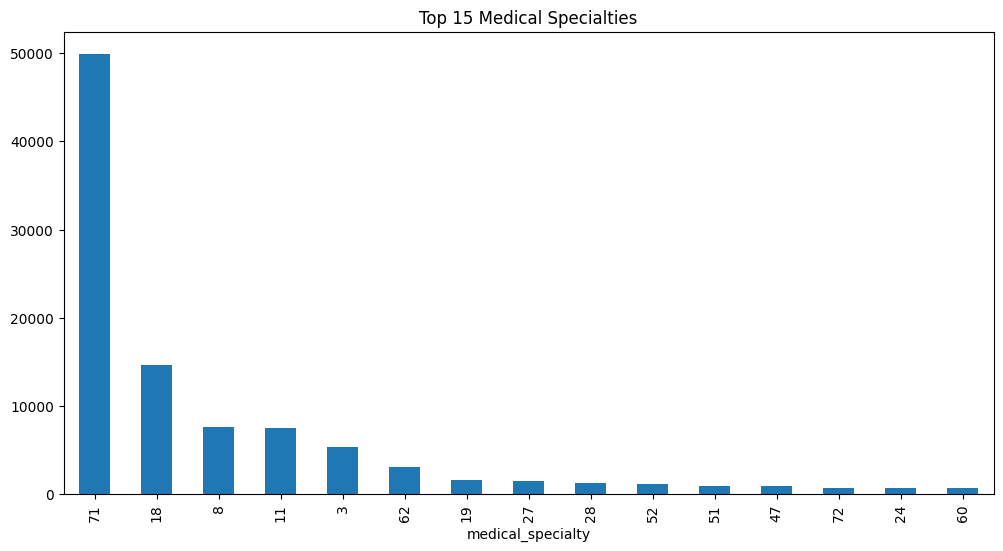

In [90]:
plt.figure(figsize=(12,6))

df['medical_specialty'].value_counts().head(15).plot(kind='bar')

plt.title('Top 15 Medical Specialties')
plt.savefig('../reports/top_specialties.png')
plt.show()


In [22]:
# Check remaining missing values

missing_after = pd.DataFrame({
    'Missing Count': df.isnull().sum()
})

print(
    missing_after[missing_after['Missing Count'] > 0]
)

               Missing Count
max_glu_serum          96420
A1Cresult              84748


In [23]:
# Check missing values column-wise

df[['medical_specialty','race','diag_1','diag_2','diag_3']].isnull().sum()

medical_specialty    0
race                 0
diag_1               0
diag_2               0
diag_3               0
dtype: int64

In [24]:
# Remove highly sparse features

df.drop(
    ['max_glu_serum', 'A1Cresult'],
    axis=1,
    inplace=True
)

# Verify dataset shape

print("Dataset Shape:", df.shape)

Dataset Shape: (101766, 44)


In [25]:
# Verify that no missing values remain

print("Total Missing Values:",
      df.isnull().sum().sum())

Total Missing Values: 0


# Categorical Feature Analysis

## Objective

Identify categorical features that require encoding before model training.

## Reason

Machine learning algorithms and PCA require numerical input.

Therefore, categorical variables must be transformed into numerical representations while preserving as much information as possible.

In [26]:
# Identify categorical columns

categorical_cols = df.select_dtypes(include=['object']).columns

print("Number of Categorical Columns:", len(categorical_cols))

print("\nCategorical Features:\n")

for col in categorical_cols:
    print(col)

Number of Categorical Columns: 32

Categorical Features:

race
gender
age
medical_specialty
diag_1
diag_2
diag_3
metformin
repaglinide
nateglinide
chlorpropamide
glimepiride
acetohexamide
glipizide
glyburide
tolbutamide
pioglitazone
rosiglitazone
acarbose
miglitol
troglitazone
tolazamide
examide
citoglipton
insulin
glyburide-metformin
glipizide-metformin
glimepiride-pioglitazone
metformin-rosiglitazone
metformin-pioglitazone
change
diabetesMed


# Encoding Strategy Analysis

## Objective

Analyze the unique values of categorical features before selecting an encoding technique.

## Reason

Different categorical variables require different encoding methods.

Examples:
- Binary variables can use simple label encoding.
- Ordered variables require ordinal encoding.
- High-cardinality variables may require special handling.

In [27]:
# Check unique values in all categorical columns

for col in categorical_cols:
    print("\n" + "="*60)
    print("Column:", col)
    print("Unique Values:", df[col].nunique())
    print(df[col].unique()[:10])


Column: race
Unique Values: 5
<ArrowStringArray>
['Caucasian', 'AfricanAmerican', 'Other', 'Asian', 'Hispanic']
Length: 5, dtype: str

Column: gender
Unique Values: 3
<ArrowStringArray>
['Female', 'Male', 'Unknown/Invalid']
Length: 3, dtype: str

Column: age
Unique Values: 10
<ArrowStringArray>
[  '[0-10)',  '[10-20)',  '[20-30)',  '[30-40)',  '[40-50)',  '[50-60)',
  '[60-70)',  '[70-80)',  '[80-90)', '[90-100)']
Length: 10, dtype: str

Column: medical_specialty
Unique Values: 73
<ArrowStringArray>
[       'Pediatrics-Endocrinology',                         'Unknown',
                'InternalMedicine',          'Family/GeneralPractice',
                      'Cardiology',                 'Surgery-General',
                     'Orthopedics',                'Gastroenterology',
 'Surgery-Cardiovascular/Thoracic',                      'Nephrology']
Length: 10, dtype: str

Column: diag_1
Unique Values: 717
<ArrowStringArray>
['250.83', '276', '648', '8', '197', '414', '428', '398', '434

# Encoding Strategy

## age
Ordinal Encoding because age groups have a natural order.

## race, gender, change, diabetesMed
Label Encoding because they contain a small number of categories.

## Medication Features
Ordinal Encoding:
- No = 0
- Steady = 1
- Up = 2
- Down = 3

## medical_specialty, diag_1, diag_2, diag_3
Label Encoding because these features contain many unique values and One-Hot Encoding would significantly increase dimensionality.

## examide, citoglipton
Removed because they contain only one unique value and provide no predictive information.

In [28]:
# Remove constant features

df.drop(
    ['examide', 'citoglipton'],
    axis=1,
    inplace=True
)

print("Dataset Shape:", df.shape)

Dataset Shape: (101766, 42)


## Age Feature Analysis

Objective:
Verify all age categories before applying ordinal encoding.

Reason:
The encoding dictionary must cover every age group present in the dataset. Missing categories would result in NaN values after mapping.

In [29]:
# Check all unique age categories

print("Number of Age Categories:",
      df['age'].nunique())

print("\nAge Categories:")

print(sorted(df['age'].unique()))

Number of Age Categories: 10

Age Categories:
['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']


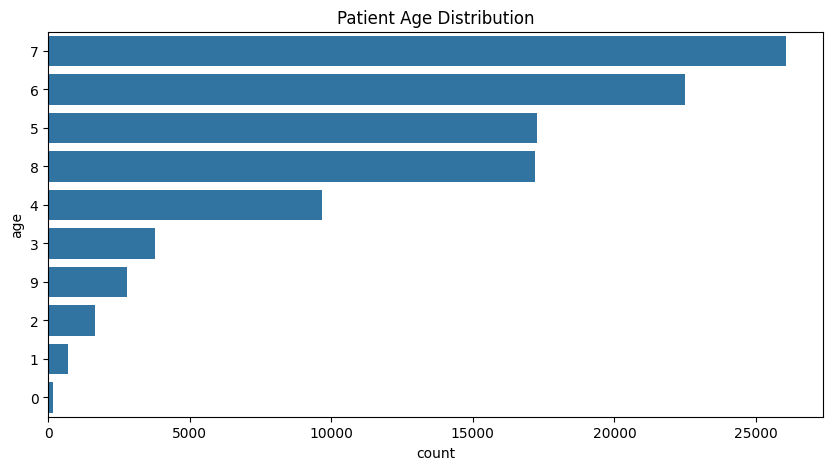

In [91]:
plt.figure(figsize=(10,5))
sns.countplot(y='age', data=df, order=df['age'].value_counts().index)
plt.title('Patient Age Distribution')
plt.savefig('../reports/age_distribution.png')
plt.show()


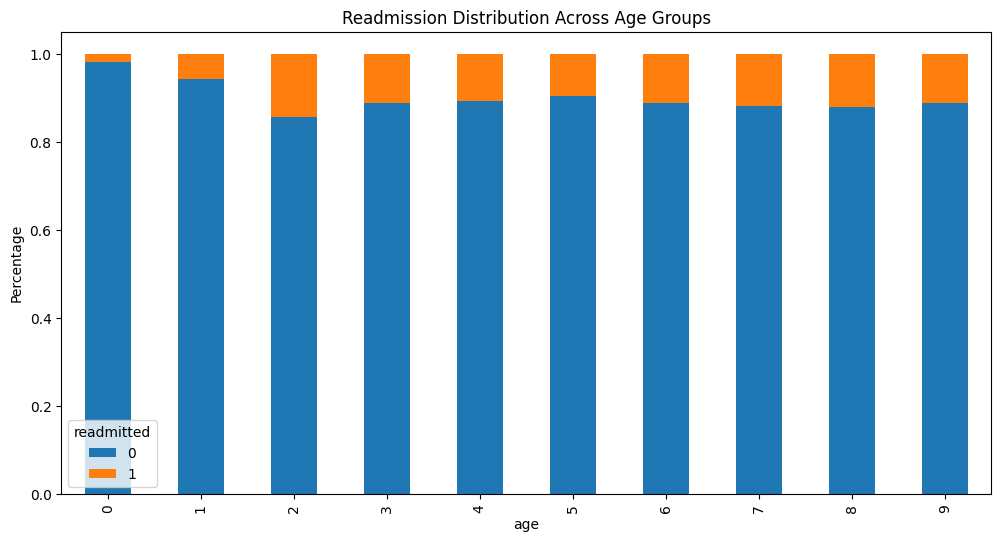

In [92]:
age_readmission = pd.crosstab(
    df['age'],
    df['readmitted'],
    normalize='index'
)

age_readmission.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Readmission Distribution Across Age Groups')
plt.ylabel('Percentage')

plt.savefig(
    '../reports/age-readmission.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [32]:
# Age groups have natural ordering

age_mapping = {
    '[0-10)':0,
    '[10-20)':1,
    '[20-30)':2,
    '[30-40)':3,
    '[40-50)':4,
    '[50-60)':5,
    '[60-70)':6,
    '[70-80)':7,
    '[80-90)':8,
    '[90-100)':9
}

df['age'] = df['age'].map(age_mapping)

# Verify encoding

print(df['age'].head(10))

0    0
1    1
2    2
3    3
4    4
5    5
6    6
7    7
8    8
9    9
Name: age, dtype: int64


# Categorical Feature Encoding

## Objective

Convert categorical variables into numerical form for machine learning and PCA.

## Encoding Methods

### Ordinal Encoding
Used for:
- age
- medication status columns

### Label Encoding
Used for:
- race
- gender
- medical_specialty
- diag_1
- diag_2
- diag_3
- change
- diabetesMed

Reason:
Machine learning models and PCA require numerical input.

In [33]:
# Medication status mapping

med_mapping = {
    'No': 0,
    'Steady': 1,
    'Up': 2,
    'Down': 3
}

medication_cols = [
    'metformin','repaglinide','nateglinide',
    'chlorpropamide','glimepiride','acetohexamide',
    'glipizide','glyburide','tolbutamide',
    'pioglitazone','rosiglitazone','acarbose',
    'miglitol','troglitazone','tolazamide',
    'insulin','glyburide-metformin',
    'glipizide-metformin',
    'glimepiride-pioglitazone',
    'metformin-rosiglitazone',
    'metformin-pioglitazone'
]

for col in medication_cols:
    df[col] = df[col].map(med_mapping)

In [34]:
print(df['metformin'].unique())

[0 1 2 3]


Verify All Medication Columns

Before moving ahead, let's make sure no medication column contains text.

In [35]:
# Verify medication encoding

for col in medication_cols:
    print(col, ":", df[col].unique())

metformin : [0 1 2 3]
repaglinide : [0 2 1 3]
nateglinide : [0 1 3 2]
chlorpropamide : [0 1 3 2]
glimepiride : [0 1 3 2]
acetohexamide : [0 1]
glipizide : [0 1 2 3]
glyburide : [0 1 2 3]
tolbutamide : [0 1]
pioglitazone : [0 1 2 3]
rosiglitazone : [0 1 2 3]
acarbose : [0 1 2 3]
miglitol : [0 1 3 2]
troglitazone : [0 1]
tolazamide : [0 1 2]
insulin : [0 2 1 3]
glyburide-metformin : [0 1 3 2]
glipizide-metformin : [0 1]
glimepiride-pioglitazone : [0 1]
metformin-rosiglitazone : [0 1]
metformin-pioglitazone : [0 1]


Label Encode Remaining Text Columns

In [36]:
from sklearn.preprocessing import LabelEncoder

# Dictionary to store encoders
label_encoders = {}

# Remaining categorical columns
label_cols = [
    'race',
    'gender',
    'medical_specialty',
    'diag_1',
    'diag_2',
    'diag_3',
    'change',
    'diabetesMed'
]

for col in label_cols:
    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

    label_encoders[col] = le

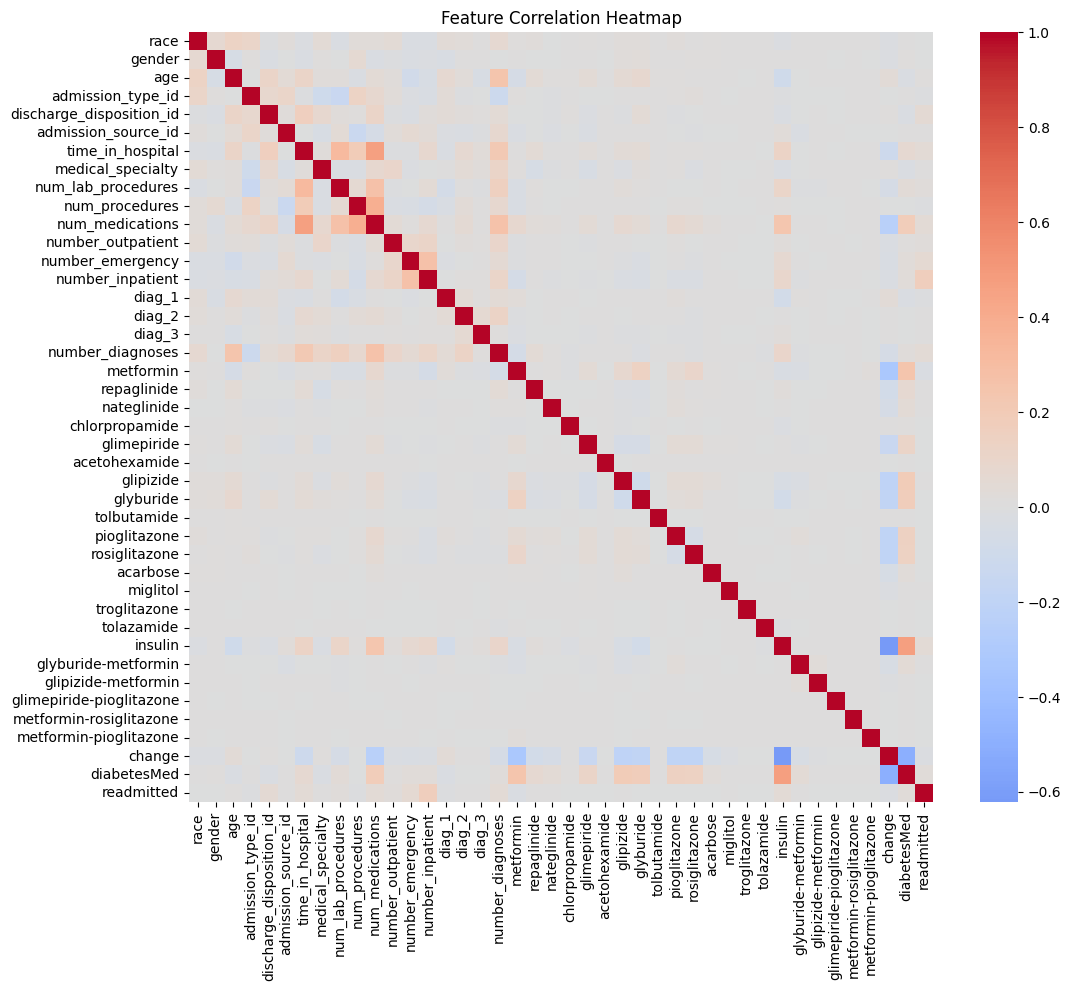

In [93]:
plt.figure(figsize=(12,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Feature Correlation Heatmap')
plt.savefig('../reports/correlation_heatmap.png')
plt.show()


In [38]:
# Check remaining object columns

print(df.select_dtypes(include=['object']).columns)

Index([], dtype='str')


In [39]:
# Check target values

print(df['readmitted'].unique())
print(df['readmitted'].value_counts())

[0 1]
readmitted
0    90409
1    11357
Name: count, dtype: int64


# Feature and Target Separation

## Objective

Separate independent variables (features) and dependent variable (target).

### Features (X)

All patient-related attributes used for prediction.

### Target (y)

#readmitted

 0 = Not readmitted within 30 days
 1 = Readmitted within 30 days

In [40]:
# Separate features and target variable

X = df.drop('readmitted', axis=1)

y = df['readmitted']

# Verify shapes

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (101766, 41)
y Shape: (101766,)


# Train-Test Split

## Objective

Split the dataset into training and testing sets.

## Reason

The model should be evaluated on unseen data to measure its real-world performance.

### Configuration

- Training Data: 80%
- Testing Data: 20%
- Stratified Split: Yes

Stratification preserves the original class distribution in both training and testing sets.

In [41]:
# Import train-test split

from sklearn.model_selection import train_test_split

# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Verify split sizes

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (81412, 41)
X_test Shape : (20354, 41)
y_train Shape: (81412,)
y_test Shape : (20354,)


# Feature Scaling

## Objective

Standardize all features before applying PCA.

## Reason

PCA is sensitive to feature magnitudes. Features with larger numerical ranges can dominate the principal components.

StandardScaler transforms features so that:

- Mean = 0
- Standard Deviation = 1

This ensures that all features contribute fairly to PCA.

In [42]:
# Import StandardScaler

from sklearn.preprocessing import StandardScaler

# Create scaler

scaler = StandardScaler()

# Fit on training data and transform

X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler

X_test_scaled = scaler.transform(X_test)

print("Training Shape:", X_train_scaled.shape)
print("Testing Shape :", X_test_scaled.shape)

Training Shape: (81412, 41)
Testing Shape : (20354, 41)


In [43]:
# Import PCA

from sklearn.decomposition import PCA

# Fit PCA on scaled training data

pca = PCA()

pca.fit(X_train_scaled)

# Calculate cumulative explained variance

import numpy as np

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

# Find components required for 95% variance

n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print("Components for 95% Variance:",
      n_components_95)

Components for 95% Variance: 35


# Principal Component Analysis (PCA)

## Objective

Reduce dimensionality while preserving 95% of the original dataset information.

## Result

PCA analysis showed that 35 principal components preserve approximately 95% of the total variance.

## Benefit

- Reduces redundant information
- Improves computational efficiency
- Helps prevent overfitting
- Retains most of the predictive information

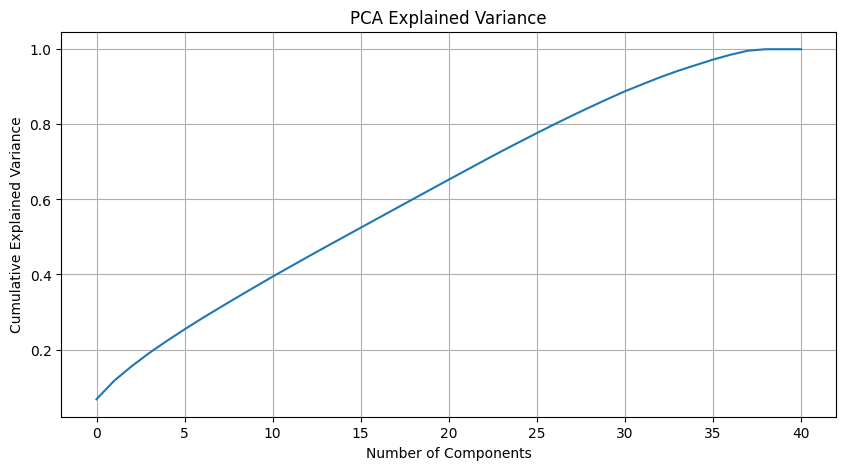

In [94]:
pca_full = PCA()

pca_full.fit(X_train_scaled)

plt.figure(figsize=(10,5))

plt.plot(
    np.cumsum(
        pca_full.explained_variance_ratio_
    )
)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

plt.title('PCA Explained Variance')

plt.grid()
plt.savefig('../reports/pca_variance.png')

plt.show()


In [45]:
# Apply PCA with 95% variance retention

pca = PCA(n_components=35)

# Transform training data

X_train_pca = pca.fit_transform(X_train_scaled)

# Transform testing data

X_test_pca = pca.transform(X_test_scaled)

# Verify shapes

print("Original Training Shape :", X_train_scaled.shape)
print("PCA Training Shape      :", X_train_pca.shape)

print()

print("Original Testing Shape  :", X_test_scaled.shape)
print("PCA Testing Shape       :", X_test_pca.shape)

Original Training Shape : (81412, 41)
PCA Training Shape      : (81412, 35)

Original Testing Shape  : (20354, 41)
PCA Testing Shape       : (20354, 35)


# Logistic Regression Model Training

## Objective

Train a Logistic Regression model on PCA-reduced features.

## Why Logistic Regression?

- Suitable for binary classification.
- Easy to interpret.
- Computationally efficient.
- Supports class imbalance handling using class_weight='balanced'.

## Imbalance Handling

The dataset is imbalanced.

Instead of generating synthetic samples, class_weight='balanced' is used to automatically assign higher importance to minority class observations.

In [46]:
# Import Logistic Regression

from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model

lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

# Train model

lr_model.fit(X_train_pca, y_train)

print("Model Training Completed Successfully")



Model Training Completed Successfully


predict() returns the final class label (0 or 1), while predict_proba() returns the probability that a patient belongs to each class. The probability values are useful for ROC-AUC analysis and risk assessment.

In [47]:
# Predict classes

y_pred = lr_model.predict(X_test_pca)

# Predict probabilities

y_prob = lr_model.predict_proba(X_test_pca)[:, 1]

print("Predictions Generated Successfully")

Predictions Generated Successfully


In [48]:
# Import evaluation metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

Accuracy : 0.6686
Precision: 0.1718
Recall   : 0.5156
F1 Score : 0.2577


In [49]:
# Import confusion matrix

from sklearn.metrics import confusion_matrix

# Generate matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[12437  5646]
 [ 1100  1171]]


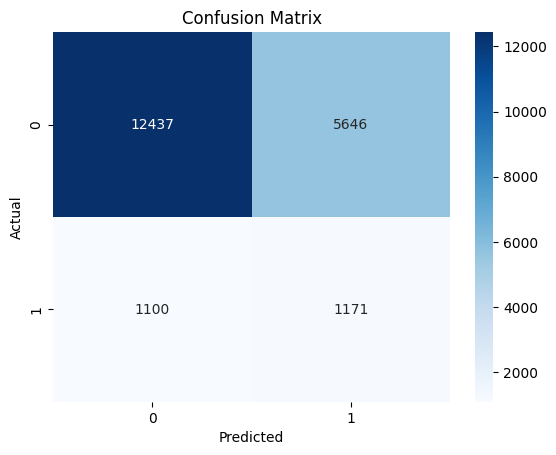

In [95]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../reports/confusion_matrix.png')
plt.show()


In [51]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.69      0.79     18083
           1       0.17      0.52      0.26      2271

    accuracy                           0.67     20354
   macro avg       0.55      0.60      0.52     20354
weighted avg       0.84      0.67      0.73     20354



In [52]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(roc_auc,4))

ROC-AUC Score: 0.6454


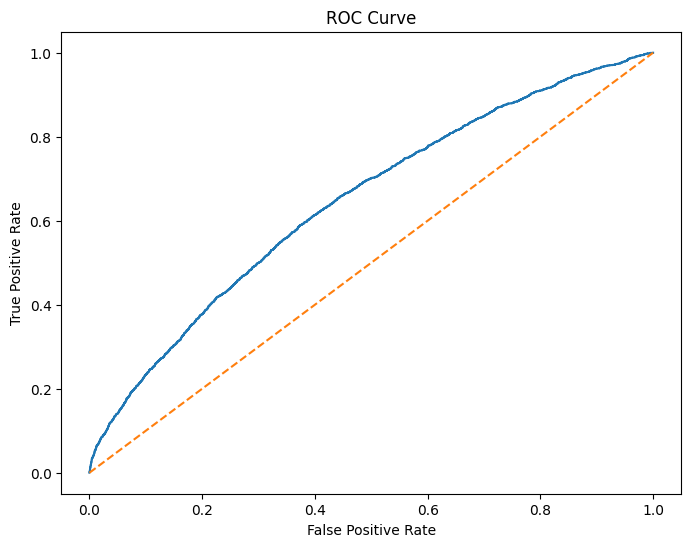

In [96]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.savefig('../reports/roc_curve.png')
plt.show()


In [54]:
# performing grid search cv while aimimg to increase accuracy of the model:

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ),
    param_grid,
    scoring='recall',
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_pca, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Recall Score:", grid.best_score_)

Best Parameters: {'C': 0.01}
Best Recall Score: 0.5015406383786425


What does this tell us?

It tells us something important:

Logistic Regression is already near its optimal performance on this dataset.

Changing C is not the bottleneck.

The limitation is likely:

Dataset complexity
Feature representation
PCA information loss

rather than Logistic Regression tuning.

###I think We need to play with PCA varinace 
Experiment 1: PCA 98%

In [55]:

# PCA retaining 98% variance

from sklearn.decomposition import PCA

pca_98 = PCA(n_components=0.98)

X_train_pca98 = pca_98.fit_transform(X_train_scaled)

X_test_pca98 = pca_98.transform(X_test_scaled)

print("Training Shape:", X_train_pca98.shape)
print("Testing Shape :", X_test_pca98.shape)

Training Shape: (81412, 37)
Testing Shape : (20354, 37)


In [56]:
# Train Logistic Regression on PCA 98% data

from sklearn.linear_model import LogisticRegression

lr_model_98 = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

lr_model_98.fit(X_train_pca98, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [57]:
# Generate predictions

y_pred_98 = lr_model_98.predict(X_test_pca98)

y_prob_98 = lr_model_98.predict_proba(X_test_pca98)[:,1]

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", round(accuracy_score(y_test, y_pred_98),4))
print("Precision:", round(precision_score(y_test, y_pred_98),4))
print("Recall   :", round(recall_score(y_test, y_pred_98),4))
print("F1 Score :", round(f1_score(y_test, y_pred_98),4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_98),4))

Accuracy : 0.6686
Precision: 0.1713
Recall   : 0.5134
F1 Score : 0.2569
ROC-AUC  : 0.6465


# PCA Variance Experiment

## Objective

Evaluate whether increasing PCA variance retention improves the performance of the Logistic Regression model.

---

## Baseline Model

### PCA Configuration

- Variance Retained: 95%
- Principal Components: 35

### Model

- Logistic Regression
- class_weight = 'balanced'
- max_iter = 1000

### Results

| Metric | Value |
|----------|----------|
| Accuracy | 66.86% |
| Precision | 17.18% |
| Recall | 51.56% |
| F1 Score | 25.77% |
| ROC-AUC | 64.54% |

---

## Experiment: PCA 98% Variance

### PCA Configuration

- Variance Retained: 98%
- Principal Components: 37

### Reason

The experiment was conducted to determine whether retaining additional variance would preserve more useful information and improve prediction performance.

# Final Baseline Model

This model is considered the baseline model for the project.

Configuration:

- StandardScaler
- PCA (95% Variance Retention)
- 35 Principal Components
- Logistic Regression
- class_weight='balanced'

Performance:

| Metric | Value |
|----------|----------|
| Accuracy | 66.86% |
| Precision | 17.18% |
| Recall | 51.56% |
| F1 Score | 25.77% |
| ROC-AUC | 64.54% |

This model will be preserved and used as the reference model for all future experiments.

In [59]:
import os
import pickle

os.makedirs("../models", exist_ok=True)

pickle.dump(scaler, open('../models/scaler.pkl', 'wb'))
pickle.dump(pca, open('../models/pca_95.pkl', 'wb'))
pickle.dump(lr_model, open('../models/hospital_readmission_model.pkl', 'wb'))
pickle.dump(label_encoders, open('../models/label_encoders.pkl', 'wb'))

print("Baseline Model Saved")

Baseline Model Saved


# Experiment 3: Threshold Tuning

## Objective

Increase recall by lowering the classification threshold from 0.50 to 0.40.

## Reason

In hospital readmission prediction, identifying more high-risk patients is often more important than maximizing overall accuracy.

## Baseline Results

Accuracy : 66.86%

Precision : 17.18%

Recall : 51.56%

F1 Score : 25.77%

ROC-AUC : 64.54%

In [60]:
# Threshold = 0.40

y_pred_40 = (y_prob >= 0.40).astype(int)

In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", round(accuracy_score(y_test, y_pred_40),4))
print("Precision:", round(precision_score(y_test, y_pred_40),4))
print("Recall   :", round(recall_score(y_test, y_pred_40),4))
print("F1 Score :", round(f1_score(y_test, y_pred_40),4))

Accuracy : 0.3281
Precision: 0.1294
Recall   : 0.8771
F1 Score : 0.2256


## Conclusion of exp 3

Lowering the threshold significantly increased recall, allowing the model to identify a much larger proportion of readmitted patients.

However, accuracy and precision decreased substantially, indicating a large increase in false positive predictions.

Therefore, the baseline threshold of 0.50 was retained as the final configuration.

## EXPERIMENT4 — PCA 99%

In [62]:
from sklearn.decomposition import PCA

pca_99 = PCA(n_components=0.99)

X_train_pca99 = pca_99.fit_transform(X_train_scaled)
X_test_pca99 = pca_99.transform(X_test_scaled)

print(X_train_pca99.shape)
print(X_test_pca99.shape)

(81412, 38)
(20354, 38)


# Experiment E4: PCA 99%

## Objective

Determine whether retaining 99% variance improves model performance.

## Reason

Additional principal components may preserve useful information that could improve classification performance.

## PCA Results

| Variance Retained | Components |
|------------------|------------|
| 95% | 35 |
| 98% | 37 |
| 99% | 38 |

In [63]:
#Train Logistic Regression on PCA 99%
from sklearn.linear_model import LogisticRegression

lr_model_99 = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)

lr_model_99.fit(X_train_pca99, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [64]:
y_pred_99 = lr_model_99.predict(X_test_pca99)

y_prob_99 = lr_model_99.predict_proba(X_test_pca99)[:,1]

In [65]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", round(accuracy_score(y_test, y_pred_99),4))
print("Precision:", round(precision_score(y_test, y_pred_99),4))
print("Recall   :", round(recall_score(y_test, y_pred_99),4))
print("F1 Score :", round(f1_score(y_test, y_pred_99),4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_99),4))

Accuracy : 0.669
Precision: 0.1712
Recall   : 0.5121
F1 Score : 0.2566
ROC-AUC  : 0.6465


# Experiment E4: PCA 99%

## Result

Increasing PCA variance retention from 95% to 99% increased the number of principal components from 35 to 38.

## Performance Comparison

| Metric | PCA 95% | PCA 99% |
|----------|----------|----------|
| Accuracy | 66.86% | 66.90% |
| Precision | 17.18% | 17.12% |
| Recall | 51.56% | 51.21% |
| F1 Score | 25.77% | 25.66% |
| ROC-AUC | 64.54% | 64.65% |

## Conclusion

The improvement in accuracy was negligible, while recall and F1 score decreased slightly.

Therefore, PCA retaining 95% variance and 35 principal components remains the preferred configuration.

# Experiment E5: Logistic Regression with liblinear Solver

## Objective

Evaluate whether the liblinear solver improves model performance compared to the default solver while keeping the same preprocessing pipeline.

## Configuration

- StandardScaler
- PCA (95% Variance)
- 35 Components
- Logistic Regression
- Solver = liblinear
- class_weight = balanced

In [66]:
from sklearn.linear_model import LogisticRegression

lr_liblinear = LogisticRegression(
    class_weight='balanced',
    solver='liblinear',
    max_iter=5000,
    random_state=42
)

lr_liblinear.fit(X_train_pca, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [67]:
# Predict classes

y_pred_liblinear = lr_liblinear.predict(X_test_pca)

# Predict probabilities

y_prob_liblinear = lr_liblinear.predict_proba(X_test_pca)[:, 1]

print("Predictions Generated Successfully")

Predictions Generated Successfully


In [68]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", round(accuracy_score(y_test, y_pred_liblinear),4))
print("Precision:", round(precision_score(y_test, y_pred_liblinear),4))
print("Recall   :", round(recall_score(y_test, y_pred_liblinear),4))
print("F1 Score :", round(f1_score(y_test, y_pred_liblinear),4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_liblinear),4))

Accuracy : 0.6687
Precision: 0.1717
Recall   : 0.5148
F1 Score : 0.2575
ROC-AUC  : 0.6454


# Experiment E5: Logistic Regression with liblinear Solver

## Objective

Evaluate whether changing the Logistic Regression solver improves performance.

## Results

| Metric | Baseline (lbfgs) | liblinear |
|----------|----------|----------|
| Accuracy | 66.86% | 66.87% |
| Precision | 17.18% | 17.17% |
| Recall | 51.56% | 51.48% |
| F1 Score | 25.77% | 25.75% |
| ROC-AUC | 64.54% | 64.54% |

## Conclusion

Changing the solver from lbfgs to liblinear did not produce any meaningful improvement.

The baseline solver was retained.

# Experiment E6: Logistic Regression with saga Solver

## Objective

Evaluate whether the saga solver improves model performance compared to the baseline model.

## Reason

Different optimization algorithms may converge to slightly different solutions and affect classification performance.

In [69]:
from sklearn.linear_model import LogisticRegression

lr_saga = LogisticRegression(
    class_weight='balanced',
    solver='saga',
    max_iter=5000,
    random_state=42
)

lr_saga.fit(X_train_pca, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [70]:
y_pred_saga = lr_saga.predict(X_test_pca)

y_prob_saga = lr_saga.predict_proba(X_test_pca)[:,1]

In [72]:
print("Accuracy :", round(accuracy_score(y_test, y_pred_saga),4))
print("Precision:", round(precision_score(y_test, y_pred_saga),4))
print("Recall   :", round(recall_score(y_test, y_pred_saga),4))
print("F1 Score :", round(f1_score(y_test, y_pred_saga),4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob_saga),4))

Accuracy : 0.6687
Precision: 0.1717
Recall   : 0.5148
F1 Score : 0.2575
ROC-AUC  : 0.6454


# Experiment Tracking Summary

| Experiment | Result | Status |
|------------|---------|---------|
| E1: Grid Search (C) | No meaningful improvement | Rejected |
| E2: PCA 98% | No meaningful improvement | Rejected |
| E3: Threshold 0.40 | Recall increased to 87.71%, accuracy dropped to 32.81% | Rejected |
| E4: PCA 99% | Negligible improvement | Rejected |
| E5: Solver = liblinear | No meaningful improvement | Rejected |
| E6: Solver = saga | No meaningful improvement | Rejected |

## Final Selected Model

- StandardScaler
- PCA (95% Variance)
- 35 Principal Components
- Logistic Regression
- class_weight='balanced'

Performance:

- Accuracy: 66.86%
- Precision: 17.18%
- Recall: 51.56%
- F1 Score: 25.77%
- ROC-AUC: 64.54%

# Precision-Recall Curve

## Objective

Evaluate model performance on an imbalanced dataset using the Precision-Recall Curve.

## Reason

ROC-AUC can sometimes give an overly optimistic view on highly imbalanced datasets.

The Precision-Recall Curve focuses on the model's ability to correctly identify the minority class (readmitted patients) and provides a clearer picture of clinical usefulness.

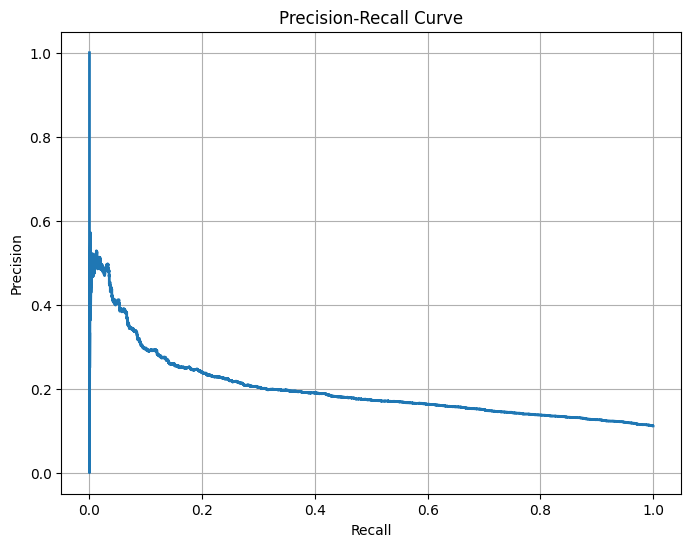

In [97]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Calculate precision and recall values

precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

# Plot curve

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=2
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.grid(True)
plt.savefig('../reports/pr_curve.png')
plt.show()


In [74]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    y_test,
    y_prob
)

print("PR-AUC Score:", round(pr_auc,4))

PR-AUC Score: 0.199


# Precision-Recall Curve Analysis

## Results

PR-AUC Score: 0.199

## Interpretation

The Precision-Recall Curve was evaluated because the dataset is highly imbalanced.

A random classifier would achieve a PR-AUC approximately equal to the positive class prevalence (~0.11).

The proposed model achieved a PR-AUC of 0.199, indicating that it performs substantially better than random guessing.

The curve demonstrates the expected tradeoff between precision and recall:

- Increasing recall results in lower precision.
- Increasing precision results in lower recall.

This behavior is consistent with hospital readmission prediction, where identifying more high-risk patients often comes at the cost of generating additional false positives.

# Stratified K-Fold Cross Validation

## Objective

Evaluate the stability and reliability of the proposed model using Stratified K-Fold Cross Validation.

## Reason

A single train-test split may produce results that depend on the specific data partition.

Stratified K-Fold Cross Validation ensures that:

- Each fold contains a similar class distribution.
- The model is evaluated on multiple train-test splits.
- Performance estimates are more reliable and robust.

## Configuration

- StandardScaler
- PCA (95% Variance Retention)
- Logistic Regression
- class_weight='balanced'
- 5-Fold Stratified Cross Validation

## Expected Outcome

If the cross-validation accuracy is close to the baseline accuracy (66.86%), it indicates that the model generalizes consistently across different subsets of the dataset.

In [75]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# Create pipeline

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('lr', LogisticRegression(
        class_weight='balanced',
        max_iter=2000,
        random_state=42
    ))
])

# Stratified K-Fold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validation accuracy

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

print("Fold Accuracies:")
print(scores)

print("\nMean Accuracy :", round(scores.mean(),4))
print("Standard Deviation :", round(scores.std(),4))

Fold Accuracies:
[0.6614916  0.6673709  0.66054144 0.67208765 0.66068884]

Mean Accuracy : 0.6644
Standard Deviation : 0.0046


# Stratified K-Fold Cross Validation Results

## Results

| Fold | Accuracy |
|--------|----------|
| Fold 1 | 66.15% |
| Fold 2 | 66.74% |
| Fold 3 | 66.05% |
| Fold 4 | 67.21% |
| Fold 5 | 66.07% |

### Mean Accuracy

66.44%

### Standard Deviation

0.46%

## Interpretation

The model demonstrated stable performance across all five folds.

The mean cross-validation accuracy (66.44%) is very close to the baseline test accuracy (66.86%), indicating that the model generalizes consistently to unseen data.

The low standard deviation (0.46%) further suggests that the model is robust and does not rely heavily on a particular train-test split.

## Conclusion

Stratified K-Fold Cross Validation confirms that the proposed PCA + Logistic Regression model provides reliable and consistent performance for hospital readmission prediction.

## some analysis for making frontened

In [76]:
print(df.drop('readmitted', axis=1).columns.tolist())

['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [77]:
import joblib

joblib.dump(X, "cleaned_X.pkl")
joblib.dump(y, "cleaned_y.pkl")

['cleaned_y.pkl']

In [78]:
X.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,...,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,2,0,0,6,25,1,1,37,41,0,...,0,0,0,0,0,0,0,0,1,0
1,2,0,1,1,1,7,3,71,59,0,...,0,0,2,0,0,0,0,0,0,1
2,0,0,2,1,1,7,2,71,11,5,...,0,0,0,0,0,0,0,0,1,1
3,2,1,3,1,1,7,2,71,44,1,...,0,0,2,0,0,0,0,0,0,1
4,2,1,4,1,1,7,1,71,51,0,...,0,0,1,0,0,0,0,0,0,1


In [79]:
for col in [
    "age",
    "insulin",
    "diabetesMed",
    "change",
    "medical_specialty",
    "diag_1",
    "glipizide"
]:
    print(col)
    print(sorted(X[col].unique())[:20])
    print()

age
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

insulin
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

diabetesMed
[np.int64(0), np.int64(1)]

change
[np.int64(0), np.int64(1)]

medical_specialty
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]

diag_1
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19)]

glipizide
[np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

